# Perpetrator Analysis in Sexual Assault Narratives

Uses `teanets` SVO extraction on r/sexualassault to identify **who** is described as perpetrating assault.

- Only `passive_approx=0` edges (genuine agent or passive with explicit "by"-phrase)
- Negated verbs removed ("do not rape", "never abuse")
- Verb phrases normalized to core lemma (`rape`, `abuse`, `assault`, `molest`)
- Agents normalized (possessive "i dad" → "dad")

In [1]:
import sys, os, re
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import teanets as tea
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Load, Clean & Normalize

In [2]:
# ── 1. Load, Clean & Normalize ─────────────────────────────────────────
# Carica i CSV (commenti + post) già estratti dalla pipeline teanets
CSV_COMMENTS = '../data/svo_output/comments_svo.csv'
CSV_POSTS    = '../data/svo_output/posts_svo.csv'

svo_raw = pd.concat(
    [pd.read_csv(CSV_COMMENTS), pd.read_csv(CSV_POSTS)],
    ignore_index=True
)
print(f'SVO rows total: {len(svo_raw):,}')

# Tieni solo le righe Agent→Event con agente genuino (passive_approx=0)
genuine = svo_raw[
    (svo_raw['passive_approx'] == 0) &
    (svo_raw['Semantic-Syntactic'] == 0) &
    (svo_raw['TEA']  == 'Agent') &
    (svo_raw['TEA2'] == 'Event')
].copy()
print(f'Agent→Event (pa=0): {len(genuine):,}')

# Verbi d'assalto da tenere
_ASSAULT_VERBS = {'rape','abuse','assault','molest'}
_VERB_MAP = {
    'rape':'rape','raping':'rape','raped':'rape','rapes':'rape',
    'abuse':'abuse','abused':'abuse','abuses':'abuse','abusing':'abuse',
    'assault':'assault','assaulted':'assault','assaults':'assault','assaulting':'assault',
    'molest':'molest','molested':'molest','molests':'molest','molesting':'molest',
}

def core_verb(v):
    if not isinstance(v, str): return None
    v = v.lower().strip()
    return _VERB_MAP.get(v, None)

genuine['core_verb'] = genuine['Node 2'].apply(core_verb)
genuine = genuine.dropna(subset=['core_verb'])

def normalize_agent(a):
    if not isinstance(a, str): return ''
    a = a.lower().strip()
    a = re.sub(r'^(i|my|her|his|their|our)\s+', '', a)  # possessivo da coref
    a = re.sub(r'\b(old|older|younger|year|little|big|late)\b', '', a)
    return re.sub(r'\s+', ' ', a).strip()

genuine['agent'] = genuine['Node 1'].apply(normalize_agent)
assault = genuine[genuine['agent'] != ''].copy()
print(f'Assault (clean):    {len(assault):,}')

print('\nVerb distribution:')
display(assault.groupby('core_verb').size().rename('n').to_frame())

# Alias per compatibilità con celle precedenti
svo_df = svo_raw


SVO rows total: 10,265,474
Agent→Event (pa=0): 2,270,075
Assault (clean):    7,179

Verb distribution:


,n
core_verb,
abuse,2659
assault,2064
molest,1715
rape,741


## 2. Categorize Perpetrators

In [3]:
# ── 2. Categorize Perpetrators (relational category + gender + voice) ───

# Pronomi per genere
_PRONOUNS_M = {'he', 'himself'}
_PRONOUNS_F = {'she', 'herself'}
_PRONOUNS_N = {
    'they','you','i','we','it','themselves','who','those',
    'someone','anyone','something','what','that','this'
}
_PRONOUNS = _PRONOUNS_M | _PRONOUNS_F | _PRONOUNS_N

# Regole relazionali per genere maschile
_RULES_M = [
    ('Family / Spouse',
     ['dad','father','brother','uncle','stepfather','grandfather',
      'grandad','husband','brother-in-law','father-in-law','nephew']),
    ('Social / Acquaintance',
     ['boyfriend','fiancé']),
    ('Institutional / Authority',
     ['priest','pastor']),
    ('Generic descriptor',
     ['guy','man','men','boy']),
]

# Regole relazionali per genere femminile
_RULES_F = [
    ('Family / Spouse',
     ['mom','mother','sister','aunt','stepmother','grandmother',
      'granny','wife','sister-in-law','mother-in-law','niece']),
    ('Social / Acquaintance',
     ['girlfriend','fiancée']),
    ('Institutional / Authority',
     ['nun']),
    ('Generic descriptor',
     ['lady','women','woman','girl']),
]

# Regole neutre / non-gendered
_RULES_N = [
    ('Family / Spouse',
     ['cousin','parent','spouse','sibling','family member']),
    ('Social / Acquaintance',
     ['friend','stranger','peer','classmate','neighbor','neighbour',
      'roommate','partner','date','ex']),
    ('Institutional / Authority',
     ['boss','coworker','teacher','coach','doctor','therapist',
      'officer','police','manager','professor','instructor','counselor']),
    ('Generic descriptor',
     ['person','people','child','kid','adult','predator','abuser','rapist']),
]


def _match_rules(s, rules):
    for cat, kws in rules:
        if any(k in s for k in kws):
            return cat
    return None


def categorize_full(s):
    """Restituisce (category, gender) per un agente normalizzato."""
    if s in _PRONOUNS_M:
        return ('Pronoun / Vague', 'Masculine')
    if s in _PRONOUNS_F:
        return ('Pronoun / Vague', 'Feminine')
    if s in _PRONOUNS_N:
        return ('Pronoun / Vague', 'Neutral')
    # Tenta match maschile
    cat = _match_rules(s, _RULES_M)
    if cat:
        return (cat, 'Masculine')
    # Tenta match femminile
    cat = _match_rules(s, _RULES_F)
    if cat:
        return (cat, 'Feminine')
    # Tenta match neutro
    cat = _match_rules(s, _RULES_N)
    if cat:
        return (cat, 'Neutral')
    return ('Other', 'Neutral')


assault[['cat', 'gender']] = assault['agent'].apply(
    lambda s: pd.Series(categorize_full(s))
)

# Voce: active vs passive (da colonna is_passive)
assault['voice'] = assault['is_passive'].apply(
    lambda x: 'Passive' if x == 1 else 'Active'
)

cat_counts = assault['cat'].value_counts()
cat_pct    = (100 * cat_counts / len(assault)).round(1)

print(f'Totale edge assault: {len(assault):,}')
print('\nDistribuzione categorie:')
display(pd.DataFrame({'n': cat_counts, '%': cat_pct}))

# ── Distribuzione genere ──
gender_counts = assault['gender'].value_counts()
gender_pct    = (100 * gender_counts / len(assault)).round(1)
print('\nDistribuzione genere agente:')
display(pd.DataFrame({'n': gender_counts, '%': gender_pct}))

# ── Distribuzione voce ──
voice_counts = assault['voice'].value_counts()
voice_pct    = (100 * voice_counts / len(assault)).round(1)
print('\nDistribuzione voce (attiva vs passiva):')
display(pd.DataFrame({'n': voice_counts, '%': voice_pct}))

Totale edge assault: 7,179

Distribuzione categorie:


,n,%
cat,,
Pronoun / Vague,4283,59.7
Generic descriptor,872,12.1
Other,865,12.0
Family / Spouse,774,10.8
Social / Acquaintance,337,4.7
Institutional / Authority,48,0.7



Distribuzione genere agente:


,n,%
gender,,
Neutral,5191,72.3
Masculine,1637,22.8
Feminine,351,4.9



Distribuzione voce (attiva vs passiva):


,n,%
voice,,
Active,6148,85.6
Passive,1031,14.4


## 3. Named Perpetrators (excluding pronouns & vague references)

Only relational and generic descriptors — the actors that reveal **social structure** of assault.

In [4]:
named = assault[assault['cat'] != 'Pronoun / Vague'].copy()
print(f'Named perpetrator edges: {len(named):,} ({100*len(named)/len(assault):.1f}% of assault edges)')

# Category breakdown
named_cats = named['cat'].value_counts()

# Top individual agents
print('\nTop 25 named perpetrators:')
display(named['agent'].value_counts().head(25).to_frame('n'))

Named perpetrator edges: 2,896 (40.3% of assault edges)

Top 25 named perpetrators:


,n
agent,
guy,210
man,110
brother,100
dad,84
people,75
father,67
cousin,59
woman,57
friend,51


## 4. Perpetrator–Verb Network

Relational perpetrators (Family, Social, Institutional) connected to their assault verbs.

Relational edges nel grafico: 32
Verbi presenti: <ArrowStringArray>
['molest', 'abuse', 'assault', 'rape']
Length: 4, dtype: str


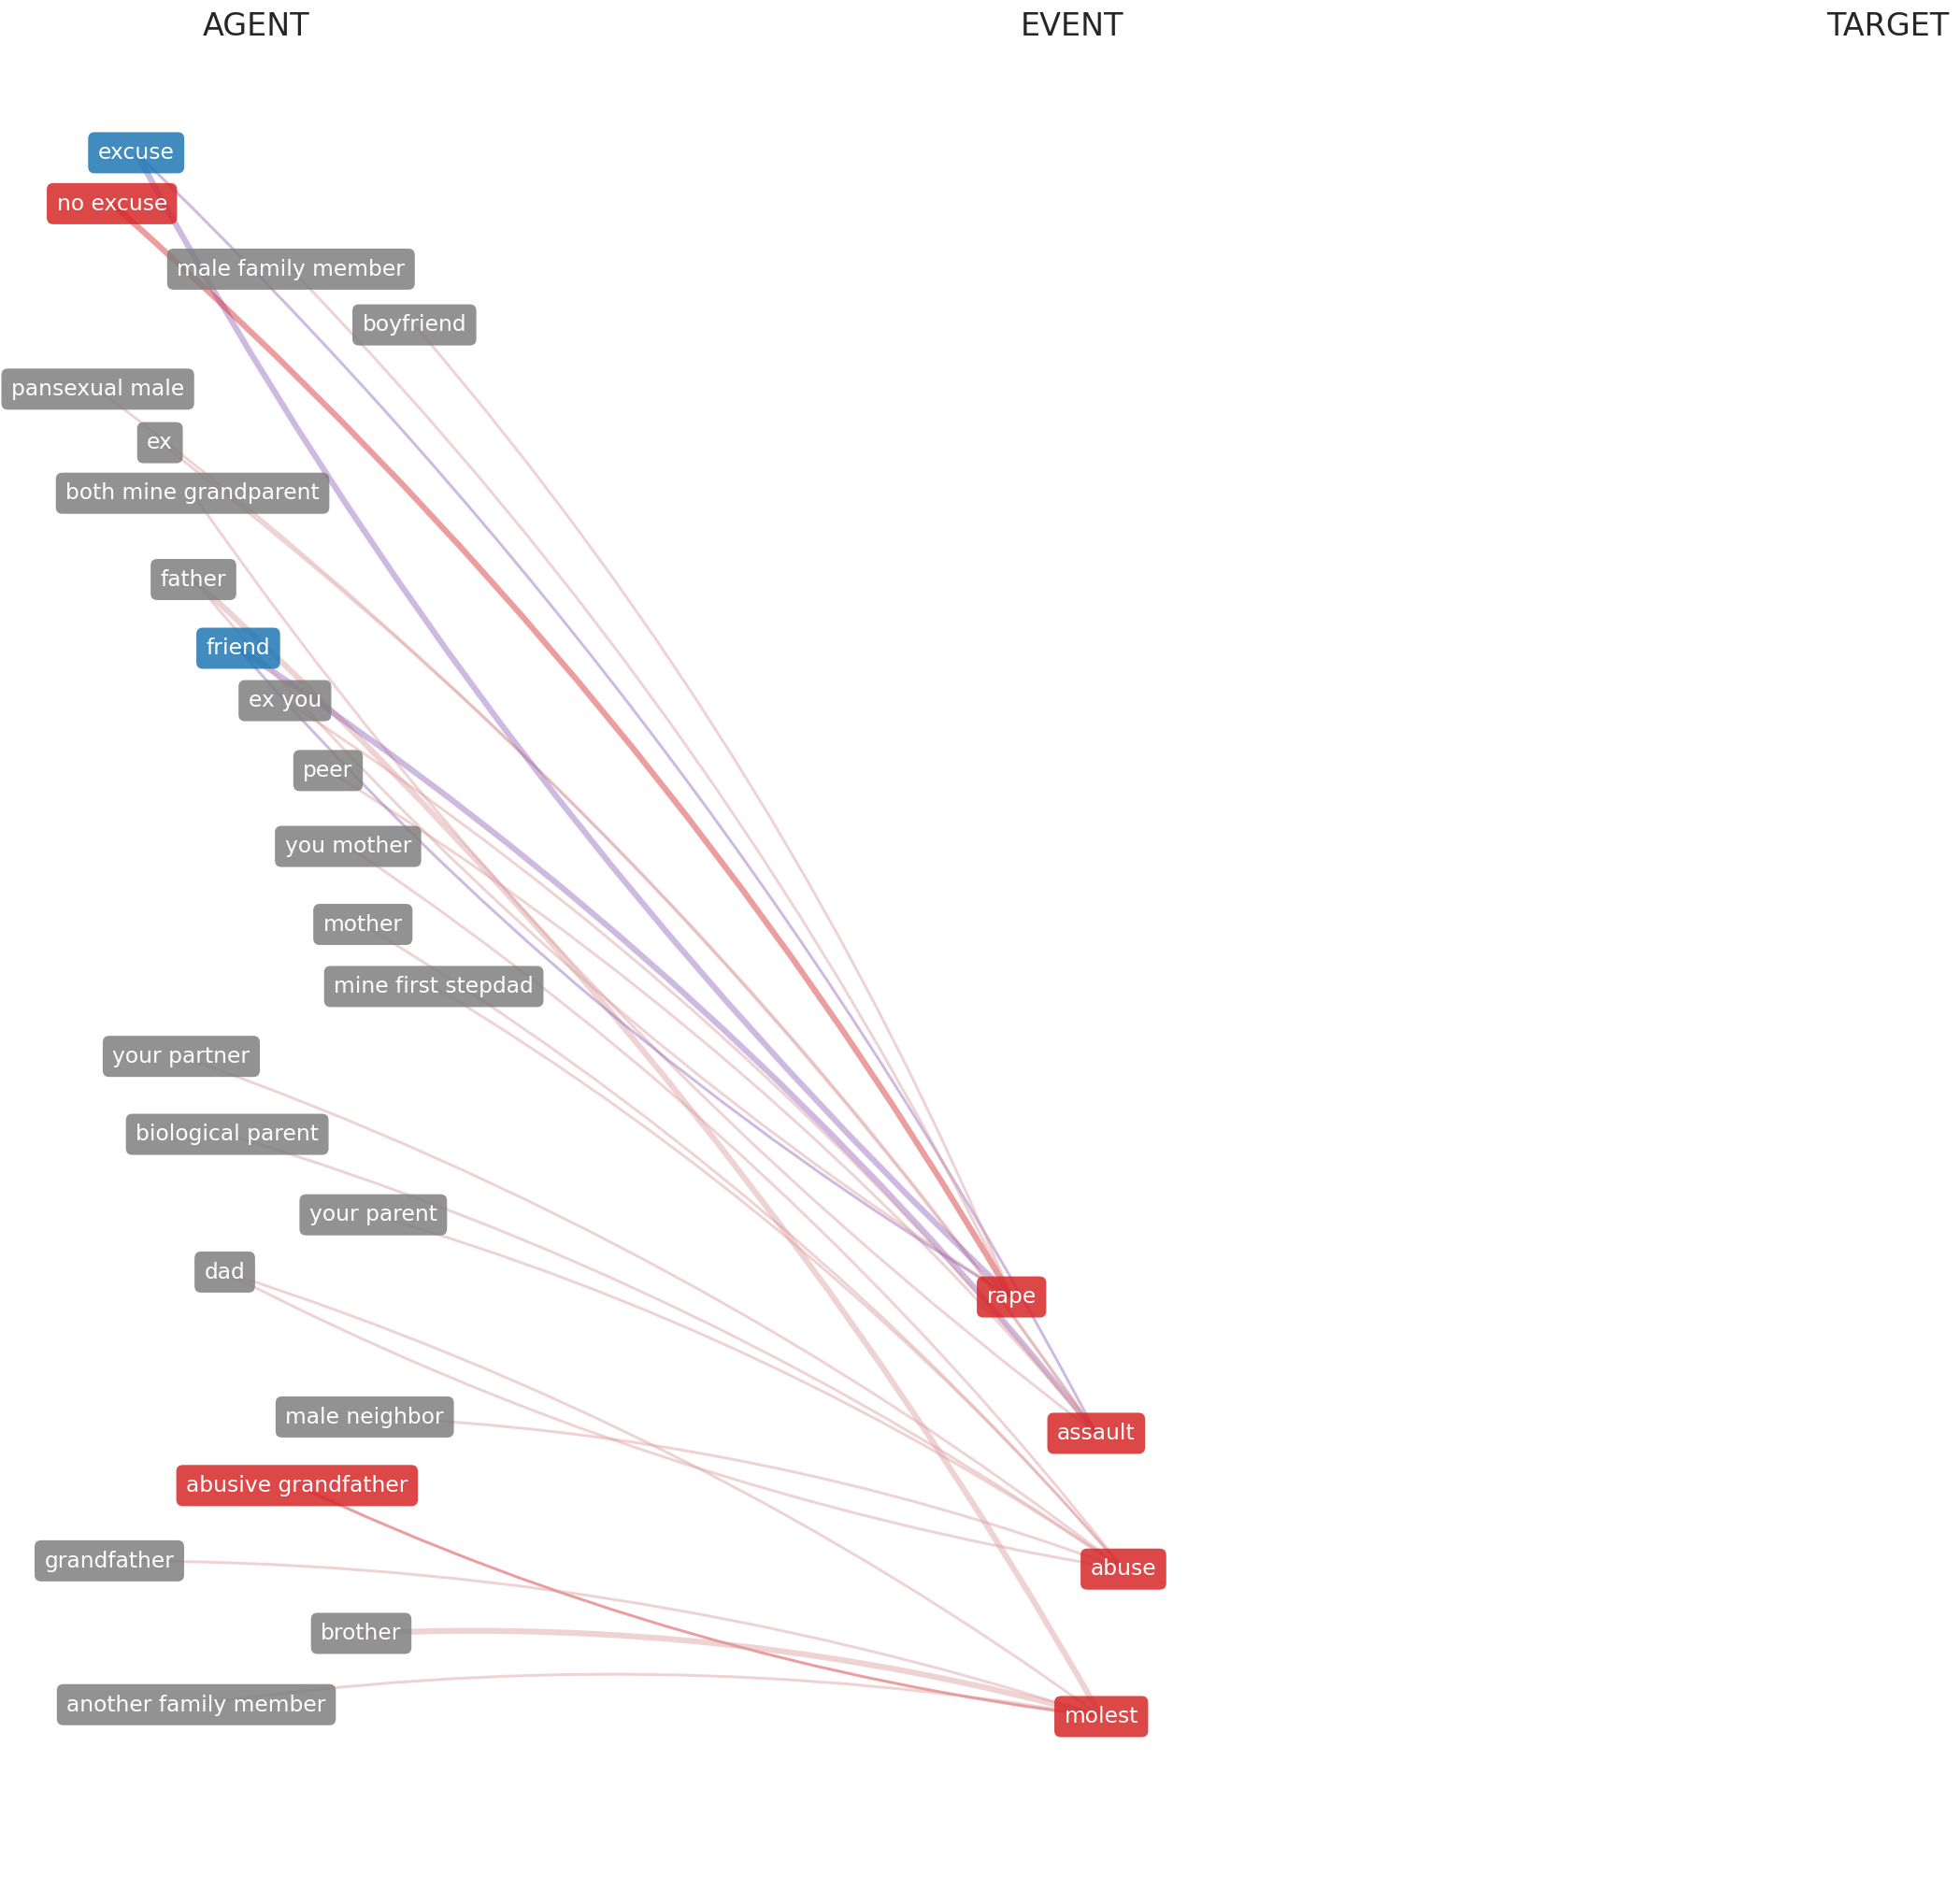

In [5]:
# Guard: ensure core_verb column exists (recover if possible)
if 'core_verb' not in named.columns:
    print("Warning: 'core_verb' column missing from 'named'. Attempting automatic recovery...")
    _R_MAP = {
        'rape':'rape','raping':'rape','raped':'rape','rapes':'rape',
        'abuse':'abuse','abused':'abuse','abuses':'abuse','abusing':'abuse',
        'assault':'assault','assaulted':'assault','assaults':'assault','assaulting':'assault',
        'molest':'molest','molested':'molest','molests':'molest','molesting':'molest',
    }
    def _rv(v):
        if not isinstance(v, str): return None
        v = v.lower().strip()
        return _R_MAP.get(v, None)
    
    if 'Node 2' in named.columns:
        named = named.copy()
        named['core_verb'] = named['Node 2'].apply(_rv)
    elif 'Node 2' in assault.columns:
        assault = assault.copy()
        assault['core_verb'] = assault['Node 2'].apply(_rv)
        named = assault[assault['cat'] != 'Pronoun / Vague'].copy()
    else:
        raise RuntimeError("Cannot recover 'core_verb'. Please re-run Cell 3.")

# ── 4. Bipartite Perpetrator–Verb Network ────────────────────────────────
# Relational perpetrators (Family, Social, Institutional) collegati ai verbi
relational = named[named['cat'].isin(
    ['Family / Spouse', 'Social / Acquaintance', 'Institutional / Authority']
)].copy()

# Campiona fino a 8 righe per verbo così tutti e 4 compaiono nel grafico
_VERB_SAMPLE = 8
net_sample = (
    relational
    .groupby('core_verb', group_keys=False).head(_VERB_SAMPLE)
)

# Sovrascrivi Node 1 / Node 2 con valori normalizzati per il grafico
net_df = net_sample.assign(**{
    'Node 1': net_sample['agent'],
    'Node 2': net_sample['core_verb']
})

print(f'Relational edges nel grafico: {len(net_df)}')
print('Verbi presenti:', net_df['core_verb'].unique())
tea.plot_svo_graph(net_df, custom_font=14)


In [6]:
## python -m teanets.batch_extract --gpu --batch-size 50 --sample-size 500 --seed 42 --output-dir ../data/svo_output --input ../data/sexualassault.csv

In [21]:
# ── Analisi Attivo / Passivo e Genere ──────────────────────────────────

# Voce: già calcolata nella cella precedente come colonna 'voice'
active  = assault[assault['voice'] == 'Active'].copy()
passive = assault[assault['voice'] == 'Passive'].copy()

print(f"Attive:  {len(active):,} edge ({100*len(active)/len(assault):.1f}%)")
print(f"Passive: {len(passive):,} edge ({100*len(passive)/len(assault):.1f}%)")

# Salva i due subset su CSV
active.to_csv('../data/svo_output/agents_active.csv',  index=False)
passive.to_csv('../data/svo_output/agents_passive.csv', index=False)
print("\nFile salvati: agents_active.csv, agents_passive.csv")

# Top 10 agenti per forma (attivo vs passivo)
for label, df in [('ATTIVO', active), ('PASSIVO', passive)]:
    agents = df['agent'].value_counts().head(25)
    print(f"\nTop 10 agenti [{label}]:")
    display(agents.to_frame('n'))

# ── Distribuzione genere × voce ──────────────────────────────────────────
print("\n── Genere × Voce ──")
cross = assault.groupby(['gender','voice']).size().unstack(fill_value=0)
cross['TOTALE'] = cross.sum(axis=1)
display(cross)

Attive:  6,148 edge (85.6%)
Passive: 1,031 edge (14.4%)

File salvati: agents_active.csv, agents_passive.csv

Top 10 agenti [ATTIVO]:


,n
agent,
i,1643
who,1240
he,489
guy,185
you,182
she,158
it,119
someone,97
man,74



Top 10 agenti [PASSIVO]:


,n
agent,
brother,53
someone,47
family member,39
man,36
cousin,33
friend,30
father,28
guy,25
dad,23



── Genere × Voce ──


voice,Active,Passive,TOTALE
gender,,,
Feminine,294,57,351
Masculine,1254,383,1637
Neutral,4600,591,5191
